# Minhash

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasketch import MinHash, MinHashLSH

In [3]:
train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

In [4]:
def discretise(spread_window):
    mean = spread_window.mean()
    std  = spread_window.std()
    z    = (spread_window - mean) / std
    
    symbols = []
    for val in z:
        if val < -1.0:       symbols.append('L')
        elif val < -0.2:     symbols.append('l')
        elif val <  0.2:     symbols.append('0')
        elif val <  1.0:     symbols.append('h')
        else:                symbols.append('H')
    return symbols

In [5]:
def shingle(symbols, k=3):
    return set(''.join(symbols[i:i+k]) for i in range(len(symbols) - k + 1))

In [6]:
df = pd.read_csv('../data/manipulated/spreads/ACN_IT.csv', index_col=0, parse_dates=True)

window = df['spread'].iloc[:20]
symbols = discretise(window)
shingles = shingle(symbols)

print(symbols)
print(shingles)

['l', 'h', 'L', 'H', 'h', '0', '0', 'l', 'l', 'H', '0', 'h', 'L', 'L', 'H', 'h', 'H', 'L', 'L', 'h']
{'hLL', 'LLH', 'LHh', 'Hh0', 'hLH', 'HhH', 'LLh', 'H0h', '0ll', 'HLL', 'llH', 'hHL', 'lH0', 'lhL', 'h00', '0hL', '00l'}


In [7]:
def make_minhash(shingles, num_perm=128):
    m = MinHash(num_perm=num_perm)
    for s in shingles:
        m.update(s.encode('utf-8'))
    return m

In [8]:
m = make_minhash(shingles)
print(m.hashvalues[:5]) 

[ 344463960   58070689  485076121 1053972325  308432411]


In [9]:
WINDOW_SIZE = 20

def build_lsh_index(spread, window_size=WINDOW_SIZE, num_perm=128):
    lsh = MinHashLSH(threshold=0.5, num_perm=num_perm)
    signatures = {}
    
    for i in range(len(spread) - window_size):
        window = spread.iloc[i:i + window_size]
        symbols = discretise(window)
        shingles = shingle(symbols)
        m = make_minhash(shingles)
        key = f"w_{i}"
        lsh.insert(key, m)
        signatures[key] = (m, i)  # store signature and start index for forward return lookup
    
    return lsh, signatures

In [10]:
spread = df['spread']
lsh, signatures = build_lsh_index(spread)
print(f"indexed {len(signatures)} windows")

indexed 2367 windows


In [11]:
def minhash_signal(spread, lsh, signatures, window_size=WINDOW_SIZE, forward_days=10, num_perm=128):
    # current window = last window_size days
    current_window = spread.iloc[-window_size:]
    symbols = discretise(current_window)
    shingles = shingle(symbols)
    query_m = make_minhash(shingles)
    
    similar_keys = lsh.query(query_m)
    
    if not similar_keys:
        return 0  # no similar windows found, no confirmation
    
    # compute forward return for each similar historical window
    forward_returns = []
    for key in similar_keys:
        _, start_idx = signatures[key]
        end_idx = start_idx + window_size + forward_days
        if end_idx < len(spread):
            forward_return = spread.iloc[start_idx + window_size + forward_days] - spread.iloc[start_idx + window_size]
            forward_returns.append(forward_return)
    
    if not forward_returns:
        return 0
    
    avg_forward_return = np.mean(forward_returns)
    return avg_forward_return

In [12]:
signal = minhash_signal(spread, lsh, signatures)
print(f"MinHash signal: {signal:.4f}")

MinHash signal: 0.0687


In [13]:
def combine_signals(gmm_signal, minhash_signal):
    if gmm_signal == 0:
        return 0
    # confirm if minhash agrees in direction, suppress if it disagrees
    if gmm_signal == 1 and minhash_signal > 0:
        return 1
    if gmm_signal == -1 and minhash_signal < 0:
        return -1
    return 0  # disagreement, so stay flat

In [ ]:
print(combine_signals(1,  0.05))   # should be  1 - confirmed long
print(combine_signals(1,  -0.05))  # should be  0 - suppressed
print(combine_signals(-1, -0.05))  # should be -1 - confirmed short
print(combine_signals(0,  -0.05))  # should be  0 - no GMM signal

1
0
-1
0


In [15]:
def compute_minhash_signals(spread, gmm_signals, lsh, signatures, window_size=WINDOW_SIZE, forward_days=10):
    minhash_signals = pd.Series(0.0, index=spread.index)
    
    # only query on days where GMM signal is non-zero
    signal_days = gmm_signals[gmm_signals != 0].index
    
    for date in signal_days:
        i = spread.index.get_loc(date)
        if i < window_size:
            continue
        
        window = spread.iloc[i - window_size:i]
        symbols = discretise(window)
        shingles = shingle(symbols)
        query_m = make_minhash(shingles)
        
        similar_keys = lsh.query(query_m)
        if not similar_keys:
            continue
        
        forward_returns = []
        for key in similar_keys:
            _, start_idx = signatures[key]
            end_idx = start_idx + window_size + forward_days
            if end_idx < len(spread) and start_idx + window_size <= i:
                fwd = spread.iloc[start_idx + window_size + forward_days] - spread.iloc[start_idx + window_size]
                forward_returns.append(fwd)
        
        if forward_returns:
            minhash_signals.loc[date] = np.mean(forward_returns)
    
    return minhash_signals

In [16]:
cointegration_pairs = pd.read_csv('../data/manipulated/cointegrated_pairs.csv')

In [17]:
MIN_SIGNALS = 200  # minimum number of non-zero GMM signals to keep a pair

active_pairs = []

for _, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0, parse_dates=True, date_format='%Y-%m-%d')
    
    n_signals = (df['signal'] != 0).sum()
    if n_signals >= MIN_SIGNALS:
        active_pairs.append(row)
        print(f"{a}/{b} — {n_signals} signals, keeping")
    else:
        print(f"{a}/{b} — {n_signals} signals, dropping")

active_pairs = pd.DataFrame(active_pairs)
active_pairs.to_csv("../data/manipulated/active_pairs.csv")
print(f"\n{len(active_pairs)} pairs kept from {len(cointegration_pairs)}")

ACN/MSI — 236 signals, keeping
CDW/HAS — 231 signals, keeping
CTSH/CSX — 222 signals, keeping
CTSH/ACN — 228 signals, keeping
AMCR/STZ — 117 signals, dropping
AMCR/APH — 160 signals, dropping
CTSH/MSI — 108 signals, dropping
CTSH/IT — 246 signals, keeping
AMCR/BLK — 174 signals, dropping
AMCR/EL — 216 signals, keeping
AMCR/APO — 0 signals, dropping
APO/CSX — 84 signals, dropping
AMCR/MSI — 238 signals, keeping
AMCR/IT — 233 signals, keeping
AMCR/ACN — 203 signals, keeping
AMCR/ARES — 297 signals, keeping
APO/MSI — 268 signals, keeping
HPQ/CRH — 132 signals, dropping
HPQ/KKR — 0 signals, dropping
HPQ/ACN — 192 signals, dropping
HPQ/IT — 71 signals, dropping
APO/ACN — 200 signals, keeping
APO/IT — 0 signals, dropping
APO/TEL — 93 signals, dropping
ECL/ACN — 204 signals, keeping
HPQ/TEL — 182 signals, dropping
ECL/MSI — 191 signals, dropping
GRMN/ACN — 198 signals, dropping
GRMN/ARES — 362 signals, keeping
GRMN/ECL — 77 signals, dropping
CRH/KKR — 0 signals, dropping
CRH/ARES — 10 signals

In [18]:
for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0, parse_dates=True)
    
    full_spread = df['spread']
    train_spread = full_spread.loc[train_start:train_end]
    lsh, signatures = build_lsh_index(train_spread)  # only learn from train

    minhash_signals = compute_minhash_signals(full_spread, df['signal'], lsh, signatures)
    
    df['minhash_signal'] = minhash_signals
    df['final_signal'] = df.apply(
        lambda r: combine_signals(r['signal'], r['minhash_signal']), axis=1
    )
    
    df.to_csv(filename)
    print(f"done: {a}/{b}")

done: ACN/MSI
done: CDW/HAS
done: CTSH/CSX
done: CTSH/ACN
done: CTSH/IT
done: AMCR/EL
done: AMCR/MSI
done: AMCR/IT
done: AMCR/ACN
done: AMCR/ARES
done: APO/MSI
done: APO/ACN
done: ECL/ACN
done: GRMN/ARES
done: HAS/IT
done: BLK/ARES
done: GRMN/IT
done: BLK/ACN
done: BLK/IT
done: BLK/CSX
done: NKE/EL
done: HAS/EL
done: HAS/CRH
done: EL/CSX
done: EL/CRH
done: EL/APO
done: NKE/CRH
done: CTSH/STZ
done: APH/CRH
done: APH/ARES
done: STZ/IT
done: STZ/ECL
done: CSX/MSI
done: EL/TEL
done: WY/HPQ
done: NKE/IT
done: WY/ARES
done: WY/CBRE
done: APH/APO
done: APH/EL
done: CTSH/AMCR
done: KKR/TEL
done: CBRE/IT
done: CSX/IT
done: HAS/APO
done: HAS/CSX
done: WY/CSX
done: EL/ARES
done: CDW/CSX
done: EL/GRMN
done: APH/CSX
done: CDW/APO
done: CTSH/ARES
done: STZ/BLK
done: STZ/CSX
done: LIN/BLK
done: AMCR/NKE
done: CDW/CRH
done: CDW/AMCR
done: CDW/WY
done: CTSH/CRH
done: LIN/CSX
done: CTSH/KKR
done: CDW/EL
done: EL/CBRE
done: APO/ARES
done: CDW/CBRE
done: CDW/KKR
done: ECL/KKR
done: APH/WY
done: STZ/ARES
d

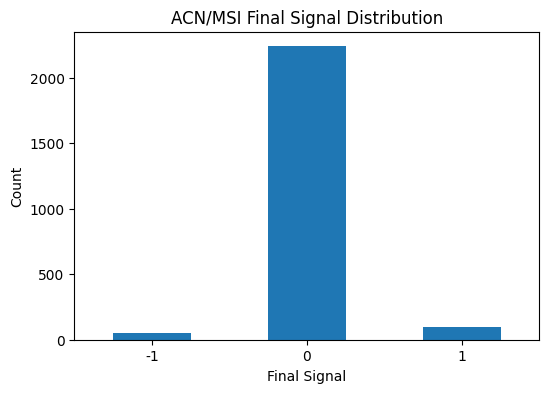

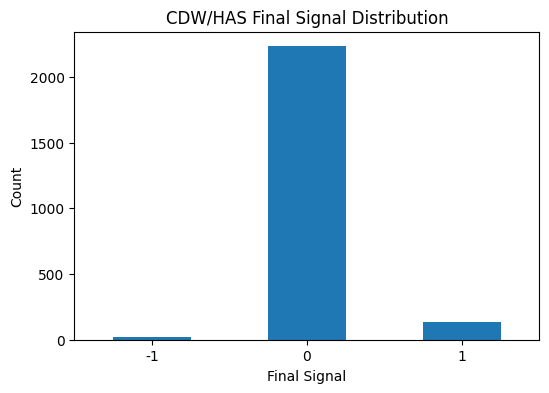

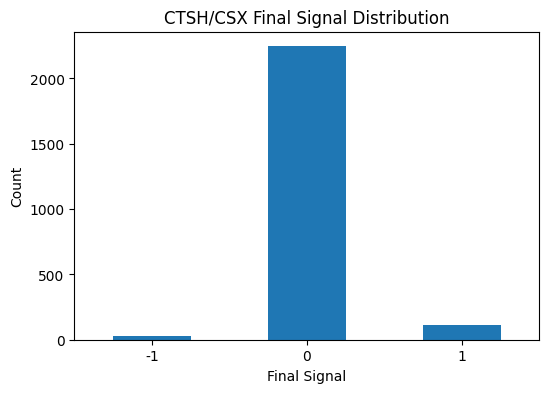

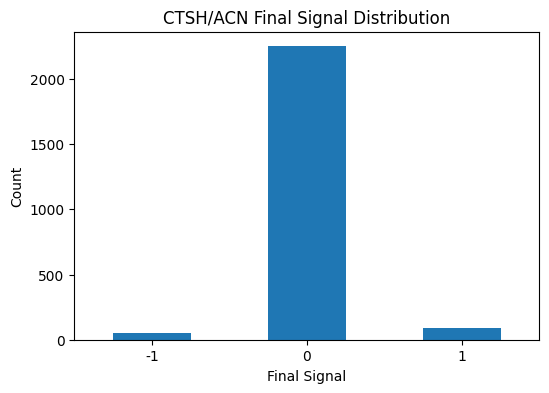

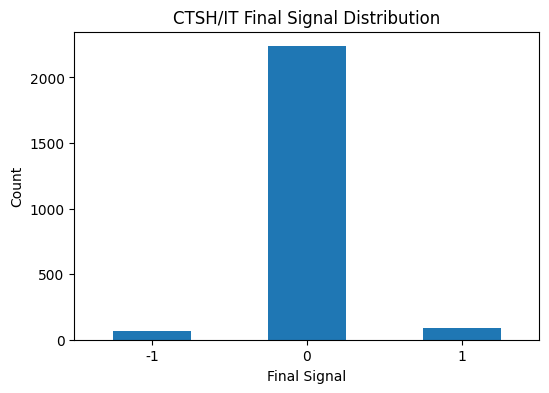

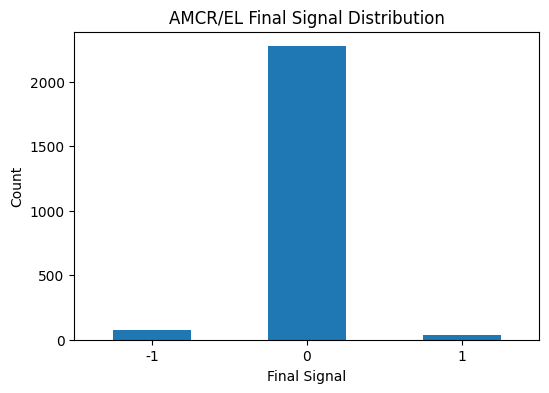

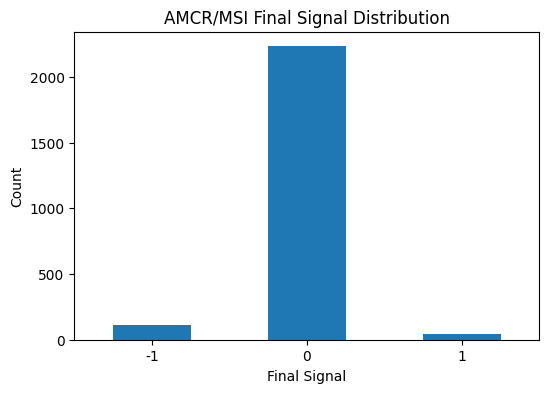

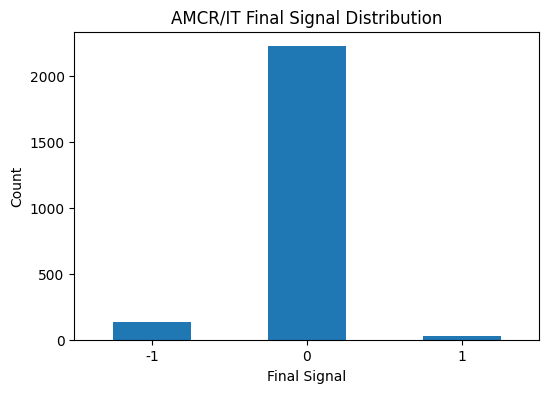

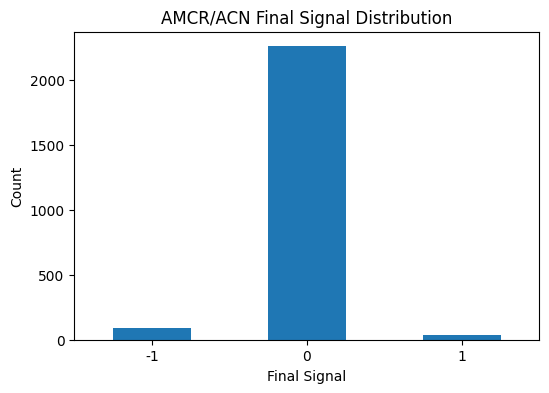

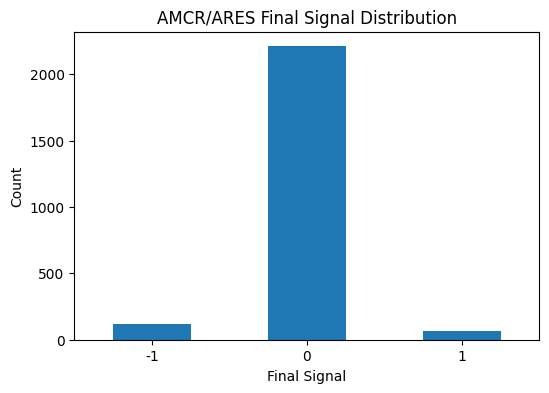

In [19]:
# plot first 10 final signal distributions
for _, row in active_pairs.head(10).iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0, parse_dates=True)
    
    plt.figure(figsize=(6, 4))
    df['final_signal'].value_counts().sort_index().plot(kind='bar')
    plt.title(f"{a}/{b} Final Signal Distribution")
    plt.xlabel('Final Signal')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

From first ten pairs, we see that we are not trading an overwhelming majority of the time.